Extrayendo características HOG para TrashNet (entrenamiento)...
TrashNet cargado en 71.84 s. Total imágenes: 2499

Extrayendo características HOG para TACO (pruebas)...
TACO cargado en 125.16 s. Total imágenes: 4374

Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

🚀 Mejor combinación encontrada (S2):
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

=== REPORTE DE CLASIFICACIÓN (S2 OPTIMIZADO) ===
              precision    recall  f1-score   support

   cardboard       0.06      0.63      0.11       232
       glass       0.05      0.08      0.06       247
       metal       0.15      0.37      0.21       517
       paper       0.10      0.11      0.10       218
     plastic       0.47      0.00      0.01      1907
       trash       0.00      0.00      0.00      1253

    accuracy                           0.09      4374
   macro avg       0.14      0.20      0.08      4374
weighted avg       0.23      0.09      0.04      4374



c:\Users\sergi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sergi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sergi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


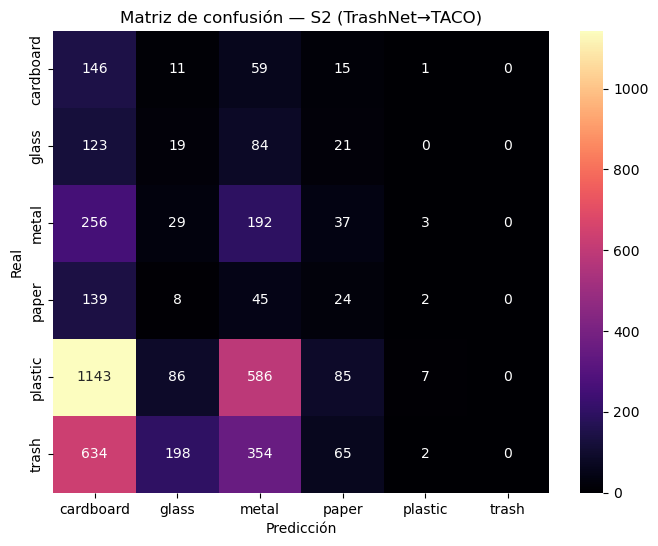

✅ Modelo optimizado S2 guardado exitosamente.


In [1]:
# ===============================================================
# ESCENARIO S2 — Train TrashNet / Test TACO (con Grid Search)
# ===============================================================
import os, time, cv2, joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Directorios
train_dir = "../../data_preprocessed/HOG_SVM/TrashNet"
test_dir  = "../../data_preprocessed/HOG_SVM/TACO"

def extract_features(data_dir):
    X, y = [], []
    for clase in sorted(os.listdir(data_dir)):
        clase_path = os.path.join(data_dir, clase)
        if not os.path.isdir(clase_path):
            continue
        for img_name in os.listdir(clase_path):
            img_path = os.path.join(clase_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            img = cv2.resize(img, (128, 128))
            features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
            X.append(features)
            y.append(clase)
    return np.array(X), np.array(y)

print("Extrayendo características HOG para TrashNet (entrenamiento)...")
start = time.time()
X_train, y_train = extract_features(train_dir)
print(f"TrashNet cargado en {time.time() - start:.2f} s. Total imágenes: {len(X_train)}")

print("\nExtrayendo características HOG para TACO (pruebas)...")
start = time.time()
X_test, y_test = extract_features(test_dir)
print(f"TACO cargado en {time.time() - start:.2f} s. Total imágenes: {len(X_test)}")

# Grid Search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

print("\nIniciando búsqueda de hiperparámetros...")
grid = GridSearchCV(SVC(probability=True), param_grid, cv=3, n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print("\n🚀 Mejor combinación encontrada (S2):")
print(grid.best_params_)

# Evaluación
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)
print("\n=== REPORTE DE CLASIFICACIÓN (S2 OPTIMIZADO) ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — S2 (TrashNet→TACO)")
plt.show()

# Guardar modelo optimizado
os.makedirs("modelos_guardados", exist_ok=True)
joblib.dump(best_svm, "modelos_guardados/hog_svm_S2_best.pkl")
print("✅ Modelo optimizado S2 guardado exitosamente.")


Extrayendo características HOG para TrashNet (entrenamiento)...
TrashNet cargado en 85.25 s — 2499 imágenes

Extrayendo características HOG para TACO (pruebas)...
TACO cargado en 148.89 s — 4374 imágenes

Normalizando características y aplicando PCA...
Características reducidas: 300 dimensiones

Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 60 candidates, totalling 180 fits

🚀 Mejor combinación encontrada (S2 Optimizado):
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

=== REPORTE DE CLASIFICACIÓN (S2 OPTIMIZADO) ===
              precision    recall  f1-score   support

   cardboard       0.05      0.77      0.10       232
       glass       0.05      0.09      0.06       247
       metal       0.23      0.01      0.03       517
       paper       0.00      0.00      0.00       218
     plastic       0.47      0.15      0.23      1907
       trash       0.00      0.00      0.00      1253

    accuracy                           0.11      4374
   macro avg       0.1

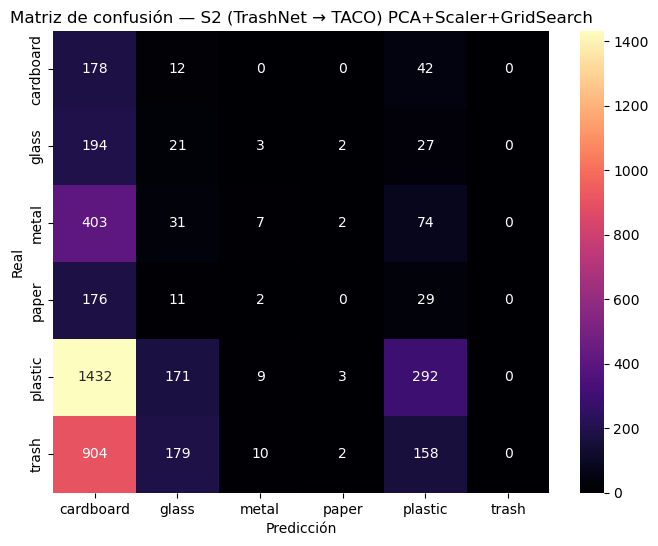

✅ Modelo, Scaler y PCA guardados exitosamente.


In [2]:
# ===============================================================
# ESCENARIO S2 — Train TrashNet → Test TACO (Optimizado)
# ===============================================================

import os, time, cv2, joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------------------------
# Función para extraer características HOG
# ----------------------------------------------
def extract_features(data_dir):
    X, y = [], []
    for clase in sorted(os.listdir(data_dir)):
        clase_path = os.path.join(data_dir, clase)
        if not os.path.isdir(clase_path): continue
        for img_name in os.listdir(clase_path):
            img_path = os.path.join(clase_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            img = cv2.resize(img, (128, 128))
            features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
            X.append(features)
            y.append(clase)
    return np.array(X), np.array(y)

# ----------------------------------------------
# Cargar datasets
# ----------------------------------------------
train_dir = "../../data_preprocessed/HOG_SVM/TrashNet"
test_dir  = "../../data_preprocessed/HOG_SVM/TACO"

print("Extrayendo características HOG para TrashNet (entrenamiento)...")
start = time.time()
X_train, y_train = extract_features(train_dir)
print(f"TrashNet cargado en {time.time() - start:.2f} s — {len(X_train)} imágenes")

print("\nExtrayendo características HOG para TACO (pruebas)...")
start = time.time()
X_test, y_test = extract_features(test_dir)
print(f"TACO cargado en {time.time() - start:.2f} s — {len(X_test)} imágenes")

# ----------------------------------------------
# Normalización y reducción con PCA
# ----------------------------------------------
print("\nNormalizando características y aplicando PCA...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=300, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Características reducidas: {X_train_pca.shape[1]} dimensiones")

# ----------------------------------------------
# Definir Grid Search
# ----------------------------------------------
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
}

print("\nIniciando búsqueda de hiperparámetros...")
grid = GridSearchCV(SVC(probability=True), param_grid, cv=3, n_jobs=-1, verbose=2)
grid.fit(X_train_pca, y_train)

print("\n🚀 Mejor combinación encontrada (S2 Optimizado):")
print(grid.best_params_)

# ----------------------------------------------
# Evaluar el mejor modelo
# ----------------------------------------------
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_pca)

print("\n=== REPORTE DE CLASIFICACIÓN (S2 OPTIMIZADO) ===")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — S2 (TrashNet → TACO) PCA+Scaler+GridSearch")
plt.show()

# ----------------------------------------------
# Guardar modelo optimizado
# ----------------------------------------------
os.makedirs("modelos_guardados", exist_ok=True)
joblib.dump(best_svm, "modelos_guardados/hog_svm_S2_best_optimized.pkl")
joblib.dump(scaler, "modelos_guardados/hog_svm_S2_scaler.pkl")
joblib.dump(pca, "modelos_guardados/hog_svm_S2_pca.pkl")

print("✅ Modelo, Scaler y PCA guardados exitosamente.")


Extrayendo características HOG para TrashNet (entrenamiento)...
TrashNet cargado en 72.29 s — 2499 imágenes

Extrayendo características HOG para TACO (pruebas)...
TACO cargado en 125.88 s — 4374 imágenes

Normalizando características y aplicando PCA...
Características reducidas: 500 dimensiones

Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 84 candidates, totalling 252 fits

🚀 Mejor combinación encontrada (S2 Avanzado):
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

=== REPORTE DE CLASIFICACIÓN (S2 OPTIMIZADO AVANZADO) ===
              precision    recall  f1-score   support

   cardboard       0.06      0.80      0.10       232
       glass       0.05      0.09      0.06       247
       metal       0.18      0.01      0.01       517
       paper       0.00      0.00      0.00       218
     plastic       0.48      0.15      0.23      1907
       trash       0.00      0.00      0.00      1253

    accuracy                           0.11      4374
   macro avg   

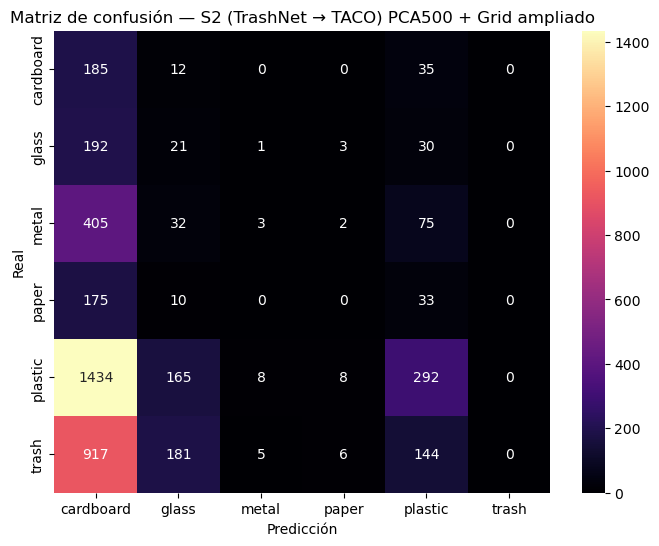

✅ Modelo avanzado S2 guardado exitosamente.


In [3]:
# ===============================================================
# ESCENARIO S2 — Train TrashNet → Test TACO (Optimización avanzada)
# ===============================================================

import os, time, cv2, joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------------------------
# Función para extraer características HOG
# ----------------------------------------------
def extract_features(data_dir):
    X, y = [], []
    for clase in sorted(os.listdir(data_dir)):
        clase_path = os.path.join(data_dir, clase)
        if not os.path.isdir(clase_path): continue
        for img_name in os.listdir(clase_path):
            img_path = os.path.join(clase_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            img = cv2.resize(img, (128, 128))
            features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
            X.append(features)
            y.append(clase)
    return np.array(X), np.array(y)

# ----------------------------------------------
# Cargar datasets
# ----------------------------------------------
train_dir = "../../data_preprocessed/HOG_SVM/TrashNet"
test_dir  = "../../data_preprocessed/HOG_SVM/TACO"

print("Extrayendo características HOG para TrashNet (entrenamiento)...")
start = time.time()
X_train, y_train = extract_features(train_dir)
print(f"TrashNet cargado en {time.time() - start:.2f} s — {len(X_train)} imágenes")

print("\nExtrayendo características HOG para TACO (pruebas)...")
start = time.time()
X_test, y_test = extract_features(test_dir)
print(f"TACO cargado en {time.time() - start:.2f} s — {len(X_test)} imágenes")

# ----------------------------------------------
# Normalización y reducción con PCA (ajustable)
# ----------------------------------------------
print("\nNormalizando características y aplicando PCA...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Puedes probar cambiando n_components entre 200, 300, 500
pca = PCA(n_components=500, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Características reducidas: {X_train_pca.shape[1]} dimensiones")

# ----------------------------------------------
# Grid Search ampliado
# ----------------------------------------------
param_grid = {
    'C': [1, 10, 100, 500],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.05, 0.01, 0.005, 0.001]
}

print("\nIniciando búsqueda de hiperparámetros...")
grid = GridSearchCV(SVC(probability=True), param_grid, cv=3, n_jobs=-1, verbose=2)
grid.fit(X_train_pca, y_train)

print("\n🚀 Mejor combinación encontrada (S2 Avanzado):")
print(grid.best_params_)

# ----------------------------------------------
# Evaluar el mejor modelo
# ----------------------------------------------
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_pca)

print("\n=== REPORTE DE CLASIFICACIÓN (S2 OPTIMIZADO AVANZADO) ===")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — S2 (TrashNet → TACO) PCA500 + Grid ampliado")
plt.show()

# ----------------------------------------------
# Guardar modelo optimizado
# ----------------------------------------------
os.makedirs("modelos_guardados", exist_ok=True)
joblib.dump(best_svm, "modelos_guardados/hog_svm_S2_best_advanced.pkl")
joblib.dump(scaler, "modelos_guardados/hog_svm_S2_scaler_advanced.pkl")
joblib.dump(pca, "modelos_guardados/hog_svm_S2_pca_advanced.pkl")

print("✅ Modelo avanzado S2 guardado exitosamente.")


In [ ]:
# ===============================================================
# ESCENARIO S3 — Train TACO → Test TrashNet (Optimización Avanzada)
# ===============================================================

import os, time, cv2, joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------------------------
# Función para extraer características HOG
# ----------------------------------------------
def extract_features(data_dir):
    X, y = [], []
    for clase in sorted(os.listdir(data_dir)):
        clase_path = os.path.join(data_dir, clase)
        if not os.path.isdir(clase_path): continue
        for img_name in os.listdir(clase_path):
            img_path = os.path.join(clase_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            img = cv2.resize(img, (128, 128))
            features, _ = hog(img, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
            X.append(features)
            y.append(clase)
    return np.array(X), np.array(y)

# ----------------------------------------------
# Cargar datasets
# ----------------------------------------------
train_dir = "../../data_preprocessed/HOG_SVM/TACO"
test_dir  = "../../data_preprocessed/HOG_SVM/TrashNet"

print("Extrayendo características HOG para TACO (entrenamiento)...")
start = time.time()
X_train, y_train = extract_features(train_dir)
print(f"TACO cargado en {time.time() - start:.2f} s — {len(X_train)} imágenes")

print("\nExtrayendo características HOG para TrashNet (pruebas)...")
start = time.time()
X_test, y_test = extract_features(test_dir)
print(f"TrashNet cargado en {time.time() - start:.2f} s — {len(X_test)} imágenes")

# ----------------------------------------------
# Normalización y reducción con PCA
# ----------------------------------------------
print("\nNormalizando características y aplicando PCA...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Puedes ajustar entre 200–500 componentes
pca = PCA(n_components=500, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Características reducidas: {X_train_pca.shape[1]} dimensiones")

# ----------------------------------------------
# Grid Search ampliado
# ----------------------------------------------
param_grid = {
    'C': [1, 10, 100, 500],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.05, 0.01, 0.005, 0.001]
}

print("\nIniciando búsqueda de hiperparámetros...")
grid = GridSearchCV(SVC(probability=True), param_grid, cv=3, n_jobs=-1, verbose=2)
grid.fit(X_train_pca, y_train)

print("\n🚀 Mejor combinación encontrada (S3 Avanzado):")
print(grid.best_params_)

# ----------------------------------------------
# Evaluar el mejor modelo
# ----------------------------------------------
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_pca)

print("\n=== REPORTE DE CLASIFICACIÓN (S3 OPTIMIZADO AVANZADO) ===")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — S3 (TACO → TrashNet) PCA500 + Grid ampliado")
plt.show()

# ----------------------------------------------
# Guardar modelo optimizado
# ----------------------------------------------
os.makedirs("modelos_guardados", exist_ok=True)
joblib.dump(best_svm, "modelos_guardados/hog_svm_S3_best_advanced.pkl")
joblib.dump(scaler, "modelos_guardados/hog_svm_S3_scaler_advanced.pkl")
joblib.dump(pca, "modelos_guardados/hog_svm_S3_pca_advanced.pkl")

print("✅ Modelo avanzado S3 guardado exitosamente.")


Extrayendo características HOG para TACO (entrenamiento)...
TACO cargado en 125.08 s — 4374 imágenes

Extrayendo características HOG para TrashNet (pruebas)...
TrashNet cargado en 48.15 s — 2499 imágenes

Normalizando características y aplicando PCA...
Características reducidas: 500 dimensiones

Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 84 candidates, totalling 252 fits
